# Visualisation des Datas et Résultats du réseau de diffusion.


---
## Configuration

Cette section regroupe les imports, les chemins et les petites fonctions utilitaires utilisees dans le reste du notebook.

In [48]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.functional import adaptive_avg_pool2d
from torch.utils.data import DataLoader, TensorDataset

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from pytorch_fid.fid_score import calculate_frechet_distance as pytorch_fid_distance
from pytorch_fid.inception import InceptionV3

from lib.PhyFID.metrics import compare_datasets
from lib.PhyFID.utils import evaluate_phyfid_dataset
from lib.cea_lib.signal2D import resize2d



In [49]:
DATA_ROOT = "../data/RT64"
PROCESSED_ROOT = os.path.join(DATA_ROOT, "processed")

TRAIN_PT = os.path.join(PROCESSED_ROOT, "training.pt")
TEST_PT = os.path.join(PROCESSED_ROOT, "test.pt")
VAL_PT = os.path.join(PROCESSED_ROOT, "validation.pt")

GENERATED_PT = "../outputs/generated/64generated_dataset.pt"
NOISE_PT = "../outputs/generated/64noise_dataset.pt"
MNIST_PT = "../data/MNIST/processed/training.pt"

LOSS_CSV = "../outputs/logs/RT64.csv"

PHYFID_ENCODER = "../outputs/phyFID/64phyfid_encoder.pt"
PHYFID_STATS = "../outputs/phyFID/64phyfid_val_stats.npz"
PHYFID_BATCH_SIZE = 128

FID_DIMS = 64
FID_BATCH_SIZE = 25
FID_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [50]:
def load_pt_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    return torch.load(path, map_location="cpu", weights_only=True)


def show_grid(images, n=16, cols=4, cmap="gray", seed=0, save=False, save_path="grid.png", title=None, colorbar=False):
    rng = np.random.default_rng(seed)
    total = images.shape[0]
    n = min(n, total)
    rows = int(np.ceil(n / cols))
    indices = rng.choice(total, size=n, replace=False)

    if colorbar:
        fig = plt.figure(figsize=(cols * 2.2 + 0.45, rows * 2.2), constrained_layout=True)
        gs = fig.add_gridspec(rows, cols + 1, width_ratios=[1] * cols + [0.06], wspace=0.02)
        axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(cols)] for r in range(rows)])
        cax = fig.add_subplot(gs[:, -1])
    else:
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2), squeeze=False, constrained_layout=True)
        cax = None

    im_ref = None
    for i, idx in enumerate(indices):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        img = images[idx].detach().cpu().numpy() if torch.is_tensor(images) else images[idx]
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]
        im_ref = ax.imshow(img, cmap=cmap)
        ax.set_title(f"idx={idx}")
        ax.axis("off")

    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    if title:
        fig.suptitle(title, fontsize=16)
    if colorbar and im_ref is not None:
        fig.colorbar(im_ref, cax=cax)
    if save:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


def print_dataset_summary(name, images):
    tensor = torch.as_tensor(images).float()
    print(
        f"{name:<12} shape={tuple(images.shape)!s:<18} dtype={images.dtype} "
        f"min={tensor.min().item():8.3f} max={tensor.max().item():8.3f} "
        f"mean={tensor.mean().item():8.3f} std={tensor.std().item():8.3f}"
    )


def normalize_generated_dataset(images, value_min=0, value_max=255):
    """Convertit les sorties DDPM vers la convention [0, 255] du dataset RT.

    Le data_loader entraîne le modèle avec x_model = 2 * x_uint8 / 255 - 1.
    L'évaluation doit donc utiliser l'inverse global de cette transformation,
    pas une normalisation min-max image par image qui détruit les amplitudes.
    """
    data = images.float() if torch.is_tensor(images) else torch.as_tensor(images).float()
    if data.min() >= value_min and data.max() <= value_max:
        return data
    normalized = (data.clamp(-1.0, 1.0) + 1.0) * 0.5
    return normalized * (value_max - value_min) + value_min


---
## Verification du Dataset

On verifie les dimensions, les types et quelques exemples visuels. Les sorties DDPM sauvegardees sont normalisees image par image dans la meme convention que les donnees RT pretraitees.

In [51]:
train_images = load_pt_dataset(TRAIN_PT)
test_images = load_pt_dataset(TEST_PT)
val_images = load_pt_dataset(VAL_PT)

generated_raw = load_pt_dataset(GENERATED_PT)
noise_raw = load_pt_dataset(NOISE_PT)
generated_dataset = normalize_generated_dataset(generated_raw)
noise_dataset = normalize_generated_dataset(noise_raw)
mnist_dataset = load_pt_dataset(MNIST_PT)
mnist_dataset = resize2d(mnist_dataset, 64, 64) 

for name, dataset in {
    "train": train_images,
    "validation": val_images,
    "test": test_images,
    "generated": generated_dataset,
    "noise": noise_dataset,
    "MNIST": mnist_dataset,
}.items():
    print_dataset_summary(name, dataset)


train        shape=(52224, 64, 64)    dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.467 std= 121.074
validation   shape=(6528, 64, 64)     dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.469 std= 121.019
test         shape=(6528, 64, 64)     dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.464 std= 121.035
generated    shape=(2048, 1, 64, 64)  dtype=torch.float32 min=   0.000 max= 255.000 mean= 123.600 std= 114.458
noise        shape=(2048, 1, 64, 64)  dtype=torch.float32 min=   0.000 max= 255.000 mean= 115.523 std= 126.708
MNIST        shape=(54000, 64, 64)    dtype=torch.float32 min=   0.000 max= 255.000 mean=  33.324 std=  73.723


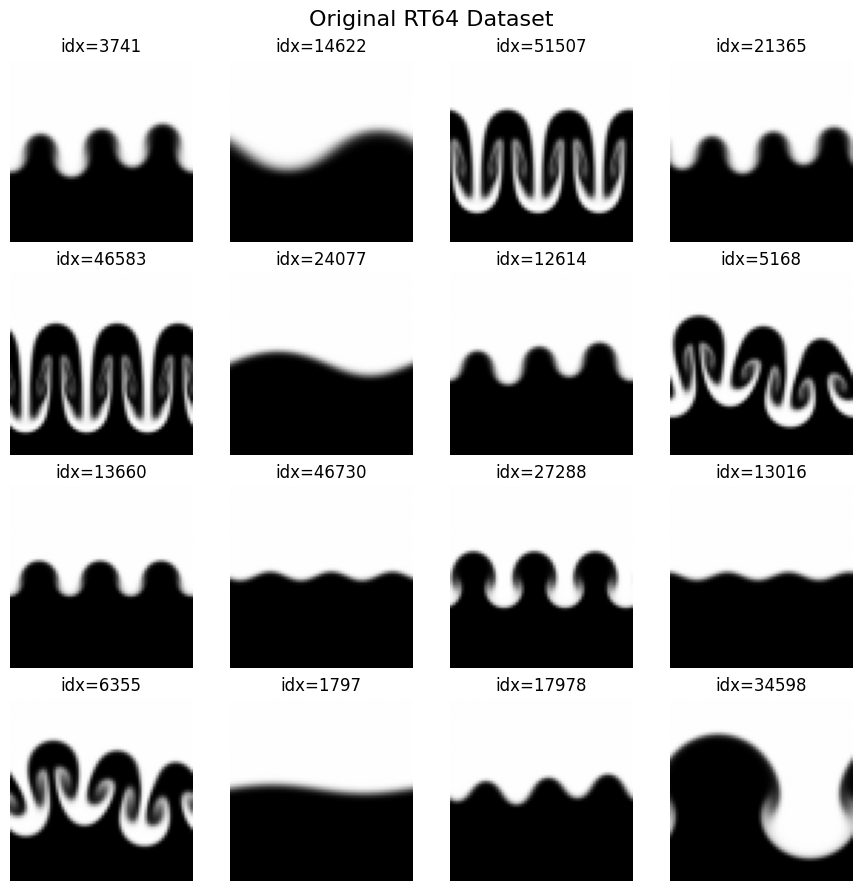

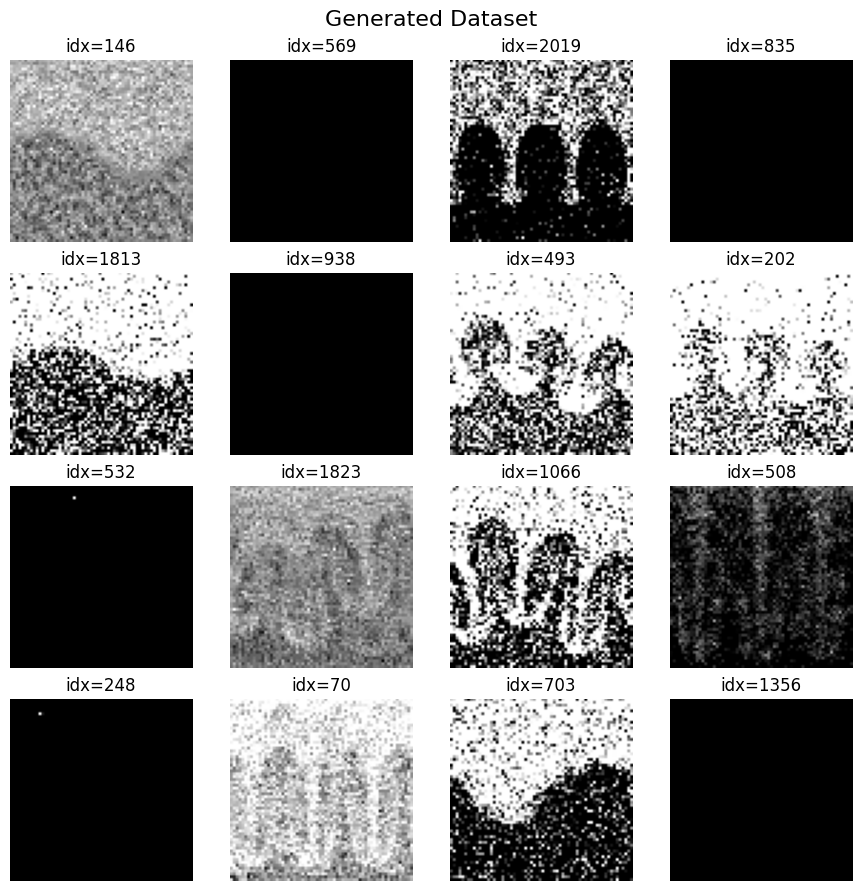

In [52]:
show_grid(train_images, n=16, cols=4, save=True, seed=20, save_path="original.png", title="Original RT64 Dataset", colorbar=False)
show_grid(generated_dataset, n=16, cols=4, save=True, seed=20, save_path="generated.png", title="Generated Dataset", colorbar=False)


---
## Information sur l'entrainement


In [53]:
def plot_loss_curve(csv_path, save=False, save_path="loss_curve.png"):
    data = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    if "epoch" not in data.dtype.names or "train_loss" not in data.dtype.names:
        raise ValueError("Le CSV doit contenir les colonnes 'epoch' et 'train_loss'.")

    epochs = data["epoch"]
    train_loss = data["train_loss"]
    val_loss = data["val_loss"] if "val_loss" in data.dtype.names else None
    best_loss = data["best_loss"] if "best_loss" in data.dtype.names else None

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(epochs, train_loss, label="train_loss")
    if val_loss is not None:
        ax[0].plot(epochs, val_loss, label="val_loss", alpha=0.8)
    if best_loss is not None:
        ax[0].plot(epochs, best_loss, label="best_loss", alpha=0.8)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("RT28 loss")
    ax[0].legend()

    eps = 1e-12
    ax[1].plot(epochs, np.log(np.clip(train_loss, eps, None)), label="log(train_loss)")
    if val_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(val_loss, eps, None)), label="log(val_loss)", alpha=0.8)
    if best_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(best_loss, eps, None)), label="log(best_loss)", alpha=0.8)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Log loss")
    ax[1].set_title("RT28 log loss")
    ax[1].legend()

    fig.tight_layout()

    if save:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


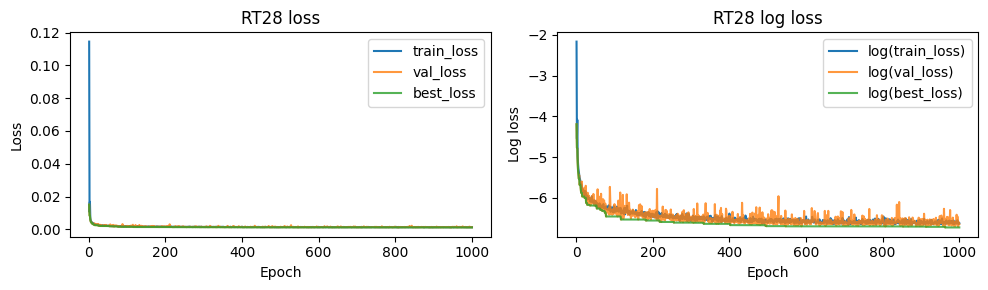

In [54]:
plot_loss_curve(LOSS_CSV, save=True, save_path="loss_curve.png")

---
# Metriques

Les métriques utilisé pour la comparaison des données génerées avec celles d'origines.

## FID

Le FID (*Frechet Inception Distance*) compare deux jeux d'images apres projection dans un espace de features. On note $\phi$ l'extracteur de features, par exemple InceptionV3 pour le FID classique, ou l'encodeur appris dans le cas du PhyFID. Pour un jeu de reference $\rho = \{\rho_i\}_{i=1}^{n}$ et un jeu genere $\varrho = \{\varrho_i\}_{i=1}^{m}$, on travaille donc avec
$$ \tilde{\rho}_i = \phi(\rho_i) \in \mathbb{R}^d, \qquad \tilde{\varrho}_i = \phi(\varrho_i) \in \mathbb{R}^d. $$

Comme pour l'ACP du notebook de comparaison, le dataset est resume dans un espace latent par sa moyenne et sa covariance. Pour le jeu de reference :
$$ \mu_{\rho} = \frac{1}{n}\sum_{i=1}^{n} \tilde{\rho}_i, \qquad
\Sigma_{\rho} = \frac{1}{n-1}\sum_{i=1}^{n}(\tilde{\rho}_i-\mu_{\rho})(\tilde{\rho}_i-\mu_{\rho})^T. $$
On definit de meme $\mu_{\varrho}$ et $\Sigma_{\varrho}$ pour les images generees.

L'hypothese du FID est que les features de chaque jeu peuvent etre approximees par une loi gaussienne multivariee,
$$ \tilde{\rho} \sim \mathcal{N}(\mu_{\rho}, \Sigma_{\rho}), \qquad \tilde{\varrho} \sim \mathcal{N}(\mu_{\varrho}, \Sigma_{\varrho}). $$
Le score est alors la distance de Frechet/Wasserstein-2 entre ces deux gaussiennes :
$$ \mathrm{FID}(\rho,\varrho) = \|\mu_{\rho}-\mu_{\varrho}\|_2^2 + \mathrm{Tr}\left(\Sigma_{\rho} + \Sigma_{\varrho} - 2(\Sigma_{\rho}\Sigma_{\varrho})^{1/2}\right). $$

Intuitivement, le premier terme mesure l'ecart entre les centres des deux nuages de features, tandis que le terme de covariance mesure l'ecart entre leurs dispersions et correlations. Un score faible signifie donc que les deux jeux sont proches statistiquement dans l'espace choisi par $\phi$.

Dans ce notebook, deux choix de $\phi$ sont testes :
- **PhyFID** : $\phi$ est un encodeur entraine sur les simulations RT, donc l'espace de comparaison est adapte au dataset physique.
- **FID Inception** : $\phi$ est InceptionV3 pre-entraine sur des images naturelles, ce qui donne une baseline standard mais pas necessairement optimale pour des champs physiques 2D.

La normalisation est critique : $\phi$ ne compare pas seulement les formes visibles, mais les valeurs numeriques fournies au reseau. Les deux ensembles doivent donc etre convertis dans la meme convention avant l'extraction des features.

### PhyFID

PhyFID apprend un encodeur sur `TRAIN_PT`, sauvegarde cet encodeur, puis compare les datasets dans l'espace de features appris. Dans ce notebook, l'encodeur et les statistiques de reference sont simplement rechargees depuis `out/` pour eviter de relancer l'entrainement.

In [55]:
PHYFID_N_IMAGES = min(1000, len(val_images) // 2, len(train_images), len(generated_dataset), len(noise_dataset), len(mnist_dataset))
phyfid_reference = val_images[:PHYFID_N_IMAGES]

phyfid_datasets = {
    "val vs val": val_images[PHYFID_N_IMAGES:2 * PHYFID_N_IMAGES],
    "val vs train": train_images[:PHYFID_N_IMAGES],
    "val vs generated": generated_dataset[:PHYFID_N_IMAGES],
    "val vs noise": noise_dataset[:PHYFID_N_IMAGES],
    "val vs MNIST": mnist_dataset[:PHYFID_N_IMAGES],
}

phyfid_scores = {
    name: compare_datasets(phyfid_reference, dataset, PHYFID_ENCODER, batch_size=PHYFID_BATCH_SIZE)
    for name, dataset in phyfid_datasets.items()
}

print(f"Comparaison PhyFID sur {PHYFID_N_IMAGES} images")
for name, score in phyfid_scores.items():
    print(f"{name:<18} {score:>10.4f}")


Comparaison PhyFID sur 1000 images
val vs val             0.0211
val vs train           0.0227
val vs generated       4.7328
val vs noise           4.5735
val vs MNIST           4.2628


### FID Inception standard

Cette baseline utilise directement l'InceptionV3 pre-entraine du depot local `lib/pytorch-fid-master`. Les cartes RT en niveaux de gris sont repetees sur trois canaux. Comme les jeux generes ne contiennent ici que 1000 images, le bloc a 64 features est utilise pour limiter les problemes de covariance singuliere ; le FID standard a 2048 features demande plutot plusieurs milliers d'images. Ces scores servent surtout a comparer l'ordre relatif des jeux de donnees.

In [56]:
def prepare_images_for_fid(images):
    """Convertit NHW/NCHW/NHWC en RGB NCHW dans [0, 1]."""
    original_dtype = torch.as_tensor(images).dtype
    images = torch.as_tensor(images).detach().cpu().float()

    if images.ndim == 3:
        images = images.unsqueeze(1)
    elif images.ndim == 4 and images.shape[-1] in (1, 3) and images.shape[1] not in (1, 3):
        images = images.permute(0, 3, 1, 2)
    if images.ndim != 4:
        raise ValueError(f"Format non supporte: {tuple(images.shape)}")

    if original_dtype == torch.uint8 or (images.min() >= 0 and images.max() > 1):
        images = images / 255.0
    elif images.min() < 0:
        images = (images + 1.0) / 2.0

    images = images.clamp(0.0, 1.0)
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    if images.shape[1] != 3:
        raise ValueError(f"FID attend 1 ou 3 canaux, recu: {images.shape[1]}")
    return images


def extract_fid_features(images, model, batch_size, device):
    images = prepare_images_for_fid(images)
    loader = DataLoader(TensorDataset(images), batch_size=batch_size, shuffle=False)
    features = []

    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            prediction = model(batch.to(device))[0]
            if prediction.shape[-2:] != (1, 1):
                prediction = adaptive_avg_pool2d(prediction, output_size=(1, 1))
            features.append(prediction.flatten(1).cpu().numpy())

    return np.concatenate(features, axis=0)


def fid_from_features(reference_features, compared_features):
    reference_mu = np.mean(reference_features, axis=0)
    reference_sigma = np.cov(reference_features, rowvar=False)
    compared_mu = np.mean(compared_features, axis=0)
    compared_sigma = np.cov(compared_features, rowvar=False)
    return float(pytorch_fid_distance(reference_mu, reference_sigma, compared_mu, compared_sigma))


In [57]:
FID_N_IMAGES = PHYFID_N_IMAGES
fid_block = InceptionV3.BLOCK_INDEX_BY_DIM[FID_DIMS]
fid_model = InceptionV3([fid_block]).to(FID_DEVICE)

val_reference_features = extract_fid_features(val_images[:FID_N_IMAGES], fid_model, FID_BATCH_SIZE, FID_DEVICE)

datasets_for_fid = {
    "val vs val": val_images[FID_N_IMAGES:2 * FID_N_IMAGES],
    "val vs train": train_images[:FID_N_IMAGES],
    "val vs generated": generated_dataset[:FID_N_IMAGES],
    "val vs noise": noise_dataset[:FID_N_IMAGES],
    "val vs MNIST": mnist_dataset[:FID_N_IMAGES],
}

fid_scores = {}
for name, dataset in datasets_for_fid.items():
    compared_features = extract_fid_features(dataset, fid_model, FID_BATCH_SIZE, FID_DEVICE)
    fid_scores[name] = fid_from_features(val_reference_features, compared_features)

print(f"Comparaison sur {FID_N_IMAGES} images (Inception: {FID_DIMS} features)")
print(f"{'Comparaison':<18} {'PhyFID':>12} {'FID Inception':>16}")
for name in datasets_for_fid:
    print(f"{name:<18} {phyfid_scores[name]:>12.4f} {fid_scores[name]:>16.4f}")

del fid_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


KeyboardInterrupt: 

---
## Metrique physique

Cette section regroupe les metriques physiques construites directement sur les champs $\rho(t,x,y)$. Elle est organisee en quatre blocs :
- preparation et normalisation des tenseurs ;
- statistiques de densite moyenne par ligne ;
- visualisation par lois skew-normal ;
- energie spectrale des fluctuations par ligne.


In [ ]:
from scipy.stats import skewnorm


def to_txy(tensor):
    """Convertit un tenseur image en forme canonique ``(t, x, y)``.

    Args:
        tensor (torch.Tensor | np.ndarray): Donnees d'entree de forme ``(t, x, y)``
            ou ``(t, 1, x, y)``.

    Returns:
        torch.Tensor: Tenseur flottant de forme ``(t, x, y)``.

    Raises:
        ValueError: Si les donnees ne peuvent pas etre interpretees comme
            un champ 2D indexe par le temps.
    """
    tensor = torch.as_tensor(tensor).float()
    if tensor.ndim == 4 and tensor.shape[1] == 1:
        tensor = tensor[:, 0]
    if tensor.ndim != 3:
        raise ValueError(f"Tenseur attendu en (t, x, y) ou (t, 1, x, y), recu {tuple(tensor.shape)}")
    return tensor


def normalize_01(tensor, normalize=True):
    """Normalise les champs dans la convention ``[0, 1]``.

    Args:
        tensor (torch.Tensor | np.ndarray): Donnees de forme ``(t, x, y)`` ou
            ``(t, 1, x, y)``.
        normalize (bool, optional): Si ``True``, divise par 255 lorsque les
            valeurs semblent etre dans la convention ``[0, 255]``. Defaults to True.

    Returns:
        torch.Tensor: Donnees flottantes de forme ``(t, x, y)``.
    """
    tensor = to_txy(tensor)
    if normalize and tensor.max() > 1.5:
        tensor = tensor / 255.0
    return tensor


def fit_skewnorm_1d(values, min_scale=1e-6, max_abs_alpha=50):
    """Ajuste une loi skew-normal sur un vecteur 1D.

    Args:
        values (array-like): Echantillons 1D a ajuster.
        min_scale (float, optional): Largeur minimale autorisee pour eviter
            une densite numeriquement singuliere. Defaults to 1e-6.
        max_abs_alpha (float, optional): Valeur absolue maximale du parametre
            d'asymetrie retourne. Defaults to 50.

    Returns:
        tuple[float, float, float]: Parametres ``(alpha, loc, scale)`` de
            ``scipy.stats.skewnorm``.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return 0.0, 0.0, min_scale

    mean = float(np.mean(values))
    std = float(np.std(values))
    if values.size < 3 or std < min_scale:
        return 0.0, mean, max(std, min_scale)

    try:
        alpha, loc, scale = skewnorm.fit(values)
        if not np.isfinite([alpha, loc, scale]).all() or scale < min_scale:
            raise ValueError("Parametres skew-normal invalides")
        alpha = float(np.clip(alpha, -max_abs_alpha, max_abs_alpha))
        return alpha, float(loc), float(scale)
    except Exception:
        return 0.0, mean, max(std, min_scale)


def fit_skewnorm_layers(layer_values):
    """Ajuste une skew-normal pour chaque ligne spatiale.

    Args:
        layer_values (array-like): Tableau de forme ``(t, x)`` contenant une
            statistique de ligne pour chaque temps et chaque ligne.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: Tableaux ``alpha``, ``loc``
            et ``scale`` de forme ``(x,)``.
    """
    layer_values = np.asarray(layer_values, dtype=float)
    params = np.array([fit_skewnorm_1d(layer_values[:, i]) for i in range(layer_values.shape[1])])
    return params[:, 0], params[:, 1], params[:, 2]


In [ ]:
val_stats = normalize_01(val_images)
generated_stats = normalize_01(generated_dataset)
mnist_stats = normalize_01(mnist_dataset)
noise_stats = normalize_01(noise_dataset)

### Statistiques de densite moyenne par lignes

On compare ici les champs physiques ligne par ligne. On note le jeu de validation $\rho(t,x,y)$ et un jeu compare $\varrho(t,x,y)$, ou $t$ indexe les images, $x$ les lignes et $y$ les colonnes. L'objectif est de reduire chaque ligne a une quantite 1D tout en conservant la structure selon $x$.

Pour chaque instant $t$ et chaque ligne $x$, on calcule d'abord la moyenne selon $y$ :
$$ m_{\rho}(t,x) = \frac{1}{N_y}\sum_{y=1}^{N_y} \rho(t,x,y), \qquad
m_{\varrho}(t,x) = \frac{1}{N_y}\sum_{y=1}^{N_y} \varrho(t,x,y). $$

On resume ensuite chaque ligne par sa moyenne temporelle :
$$ \tilde{\rho}_l(x) = \frac{1}{N_t}\sum_{t=1}^{N_t} m_{\rho}(t,x), \qquad
\tilde{\varrho}_l(x) = \frac{1}{N_t}\sum_{t=1}^{N_t} m_{\varrho}(t,x). $$

La dispersion temporelle des moyennes de ligne est definie par :
$$ \sigma_{\rho,l}(x) = \sqrt{\frac{1}{N_t}\sum_{t=1}^{N_t}\left(m_{\rho}(t,x)-\tilde{\rho}_l(x)\right)^2}, \qquad
\sigma_{\varrho,l}(x) = \sqrt{\frac{1}{N_t}\sum_{t=1}^{N_t}\left(m_{\varrho}(t,x)-\tilde{\varrho}_l(x)\right)^2}. $$

Autrement dit, la fluctuation d'une ligne autour de son profil moyen est
$$ \delta m_{\rho}(t,x) = m_{\rho}(t,x)-\tilde{\rho}_l(x), $$
et la variance temporelle correspond a la moyenne quadratique de cette fluctuation :
$$ \sigma_{\rho,l}^2(x) = \overline{\delta m_{\rho}^2}(x). $$
L'ecart-type $\sigma_{\rho,l}(x)$ est donc l'amplitude typique des fluctuations temporelles de la ligne $x$.

Les distances utilisees dans `line_metric` comparent alors les profils selon $x$ :
$$ d_{\mu}(\rho,\varrho) = \frac{1}{N_x}\left\|\tilde{\rho}_l-\tilde{\varrho}_l\right\|_2, \qquad
d_{\sigma}(\rho,\varrho) = \frac{1}{N_x}\left\|\sigma_{\rho,l}-\sigma_{\varrho,l}\right\|_2. $$

Enfin, pour visualiser la distribution temporelle de chaque ligne, on ajuste une loi skew-normal a chaque vecteur $m_{\rho}(:,x)$ :
$$ m_{\rho}(:,x) \sim \mathrm{SN}\left(\alpha_{\rho,l}(x), \xi_{\rho,l}(x), \omega_{\rho,l}(x)\right), $$
et de meme pour $m_{\varrho}(:,x)$. Les joyplots affichent ces lois ajustees ligne par ligne, ce qui permet de voir a la fois le deplacement du centre et l'asymetrie de la distribution.


In [ ]:
def as_txy_numpy(data):
    """Convertit des champs images en ``ndarray`` de forme ``(t, x, y)``.

    Args:
        data (torch.Tensor | np.ndarray): Donnees de forme ``(t, x, y)`` ou
            ``(t, 1, x, y)``.

    Returns:
        np.ndarray: Donnees flottantes de forme ``(t, x, y)``.

    Raises:
        ValueError: Si la forme des donnees n'est pas supportee.
    """
    if torch.is_tensor(data):
        data = data.detach().cpu().numpy()
    data = np.asarray(data, dtype=float)
    if data.ndim == 4 and data.shape[1] == 1:
        data = data[:, 0]
    if data.ndim != 3:
        raise ValueError(f"Donnees attendues en (t, x, y) ou (t, 1, x, y), recu {data.shape}")
    return data


def line_metric(validation, generated, metric_name="mu"):
    """Compare deux jeux de champs par profils de lignes.

    Args:
        validation (torch.Tensor | np.ndarray): Jeu de reference de forme
            ``(t, x, y)`` ou ``(t, 1, x, y)``.
        generated (torch.Tensor | np.ndarray): Jeu compare de forme
            ``(t, x, y)`` ou ``(t, 1, x, y)``.
        metric_name (str, optional): Type de profil compare. ``"mu"`` compare
            la moyenne temporelle de ``mean_y`` ; ``"sigma"`` compare son
            ecart-type temporel. Defaults to "mu".

    Returns:
        tuple[float, np.ndarray, np.ndarray]: Distance normalisee, profil du
            jeu compare et profil du jeu de validation.

    Raises:
        ValueError: Si les deux jeux n'ont pas le meme nombre de lignes ou si
            ``metric_name`` n'est pas supporte.
    """
    validation = as_txy_numpy(validation)
    generated = as_txy_numpy(generated)
    if validation.shape[1] != generated.shape[1]:
        raise ValueError(f"Le nombre de lignes x doit etre le meme pour validation et generated: {validation.shape[1]} vs {generated.shape[1]}")

    n_x = validation.shape[1]
    mu_val = validation.mean(axis=2)
    mu_gen = generated.mean(axis=2)
    if metric_name == "mu":
        MU_l_val = np.mean(mu_val, axis=0)
        MU_l_gen = np.mean(mu_gen, axis=0)
        distance = np.linalg.norm(MU_l_val - MU_l_gen) / n_x
        return distance, MU_l_gen, MU_l_val 
    elif metric_name == "sigma":
        SIGMA_l_val = np.std(mu_val, axis=0)
        SIGMA_l_gen = np.std(mu_gen, axis=0)
        distance = np.linalg.norm(SIGMA_l_val - SIGMA_l_gen) / n_x
        return distance, SIGMA_l_gen, SIGMA_l_val
    else:
        raise ValueError(f"Metric non supportee: {metric_name}")
    

def get_alpha(data):
    """Ajuste une skew-normal sur les moyennes de lignes d'un jeu.

    Args:
        data (torch.Tensor | np.ndarray): Donnees de forme ``(t, x, y)`` ou
            ``(t, 1, x, y)``.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: Parametres ``alpha``, ``loc``
            et ``scale`` de forme ``(x,)``.
    """
    data = as_txy_numpy(data)
    d = data.mean(axis=2)
    ALPHA_l_val, LOC_l_val, SCALE_l_val = fit_skewnorm_layers(d)
    return ALPHA_l_val, LOC_l_val, SCALE_l_val


### Visualisation par joyplots skew-normal

Les fonctions suivantes affichent les lois skew-normal ajustees aux distributions temporelles de chaque ligne. Les courbes sont normalisees en hauteur pour rendre le deplacement des centres et l'asymetrie plus lisibles.


In [ ]:
def skewnorm_pdf(x, alpha, loc, scale):
    """Evalue la densite d'une loi skew-normal.

    Args:
        x (np.ndarray): Points ou evaluer la densite.
        alpha (float): Parametre d'asymetrie.
        loc (float): Parametre de localisation.
        scale (float): Parametre d'echelle.

    Returns:
        np.ndarray: Valeurs de densite aux points ``x``.
    """
    scale = float(scale)
    if scale <= 0:
        return np.zeros_like(x)
    return skewnorm.pdf(x, float(alpha), loc=float(loc), scale=scale)


def plot_skewnorm_joyplot(n_curves, alpha1, loc1, scale1, alpha2=None, loc2=None, scale2=None, *, ax=None, title="", label1="Validation", label2="Generated", color1="tab:blue", color2="tab:orange", x_min=-0.05, x_max=1.05):
    """Trace un joyplot de lois skew-normal par ligne.

    Args:
        n_curves (int): Nombre de lignes a afficher entre le bord haut et le
            bord bas du champ.
        alpha1 (array-like): Parametres d'asymetrie du premier jeu, forme ``(x,)``.
        loc1 (array-like): Parametres de localisation du premier jeu, forme ``(x,)``.
        scale1 (array-like): Parametres d'echelle du premier jeu, forme ``(x,)``.
        alpha2 (array-like, optional): Parametres d'asymetrie du second jeu.
            Defaults to None.
        loc2 (array-like, optional): Parametres de localisation du second jeu.
            Defaults to None.
        scale2 (array-like, optional): Parametres d'echelle du second jeu.
            Defaults to None.
        ax (matplotlib.axes.Axes, optional): Axe sur lequel tracer. Defaults to None.
        title (str, optional): Titre du sous-plot. Defaults to "".
        label1 (str, optional): Label du premier jeu. Defaults to "Validation".
        label2 (str, optional): Label du second jeu. Defaults to "Generated".
        color1 (str, optional): Couleur du premier jeu. Defaults to "tab:blue".
        color2 (str, optional): Couleur du second jeu. Defaults to "tab:orange".
        x_min (float, optional): Borne minimale de l'axe horizontal. Defaults to -0.05.
        x_max (float, optional): Borne maximale de l'axe horizontal. Defaults to 1.05.

    Returns:
        matplotlib.axes.Axes: Axe contenant le joyplot.

    Raises:
        ValueError: Si les tableaux de parametres n'ont pas des formes compatibles.
    """
    alpha1 = np.asarray(alpha1)
    loc1 = np.asarray(loc1)
    scale1 = np.asarray(scale1)
    if alpha1.shape != loc1.shape or loc1.shape != scale1.shape:
        raise ValueError("alpha1, loc1 et scale1 doivent avoir la meme forme")

    has_second = alpha2 is not None and loc2 is not None and scale2 is not None
    if has_second:
        alpha2 = np.asarray(alpha2)
        loc2 = np.asarray(loc2)
        scale2 = np.asarray(scale2)
        if alpha2.shape != loc2.shape or loc2.shape != scale2.shape or loc2.shape != loc1.shape:
            raise ValueError("alpha2/loc2/scale2 doivent avoir la meme forme que alpha1/loc1/scale1")

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 3.5))

    n_curves = min(int(n_curves), len(loc1))
    selected_idx = np.linspace(0, len(loc1) - 1, n_curves, dtype=int)
    x = np.linspace(x_min, x_max, 800)
    spacing = 1.0
    height = 0.55

    for plot_idx, layer_idx in enumerate(selected_idx):
        offset = plot_idx * spacing

        y1 = skewnorm_pdf(x, alpha1[layer_idx], loc1[layer_idx], scale1[layer_idx])
        y1 = y1 / y1.max() * height if y1.max() > 0 else y1
        ax.fill_between(x, offset, offset + y1, color=color1, alpha=0.35)
        ax.plot(x, offset + y1, color=color1, linewidth=1.2, label=label1 if plot_idx == 0 else None)
        ax.axvline(loc1[layer_idx], ymin=offset / (n_curves * spacing), ymax=(offset + height) / (n_curves * spacing), color=color1, linestyle="--", linewidth=0.8, alpha=0.7)

        if has_second:
            y2 = skewnorm_pdf(x, alpha2[layer_idx], loc2[layer_idx], scale2[layer_idx])
            y2 = y2 / y2.max() * height if y2.max() > 0 else y2
            ax.fill_between(x, offset, offset + y2, color=color2, alpha=0.30)
            ax.plot(x, offset + y2, color=color2, linewidth=1.2, label=label2 if plot_idx == 0 else None)
            ax.axvline(loc2[layer_idx], ymin=offset / (n_curves * spacing), ymax=(offset + height) / (n_curves * spacing), color=color2, linestyle="--", linewidth=0.8, alpha=0.7)

    ax.set_xlim(x_min, x_max)
    ax.set_yticks(np.arange(n_curves) * spacing)
    ax.set_yticklabels([f"y={i}" for i in selected_idx])
    ax.set_xlabel(r"$\mu_l$")
    ax.set_ylabel("Colonne y constant")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    if has_second:
        ax.legend(loc="upper right")
    return ax


In [ ]:
mu_l_dist_gen, mu_l_gen, mu_l_val = line_metric(val_stats, generated_stats, metric_name="mu")
mu_l_dist_noise, mu_l_noise, _ = line_metric(val_stats, noise_stats, metric_name="mu")
mu_l_dist_mnist, mu_l_mnist, _ = line_metric(val_stats, mnist_stats, metric_name="mu")

sigma_l_dist_gen, sigma_l_gen, sigma_l_val = line_metric(val_stats, generated_stats, metric_name="sigma")
sigma_l_dist_noise, sigma_l_noise, _ = line_metric(val_stats, noise_stats, metric_name="sigma")
sigma_l_dist_mnist, sigma_l_mnist, _ = line_metric(val_stats, mnist_stats, metric_name="sigma")

alpha_l_val, loc_l_val, scale_l_val = get_alpha(val_stats)
alpha_l_generated, loc_l_generated, scale_l_generated = get_alpha(generated_stats)
alpha_l_mnist, loc_l_mnist, scale_l_mnist = get_alpha(mnist_stats)
alpha_l_noise, loc_l_noise, scale_l_noise = get_alpha(noise_stats)

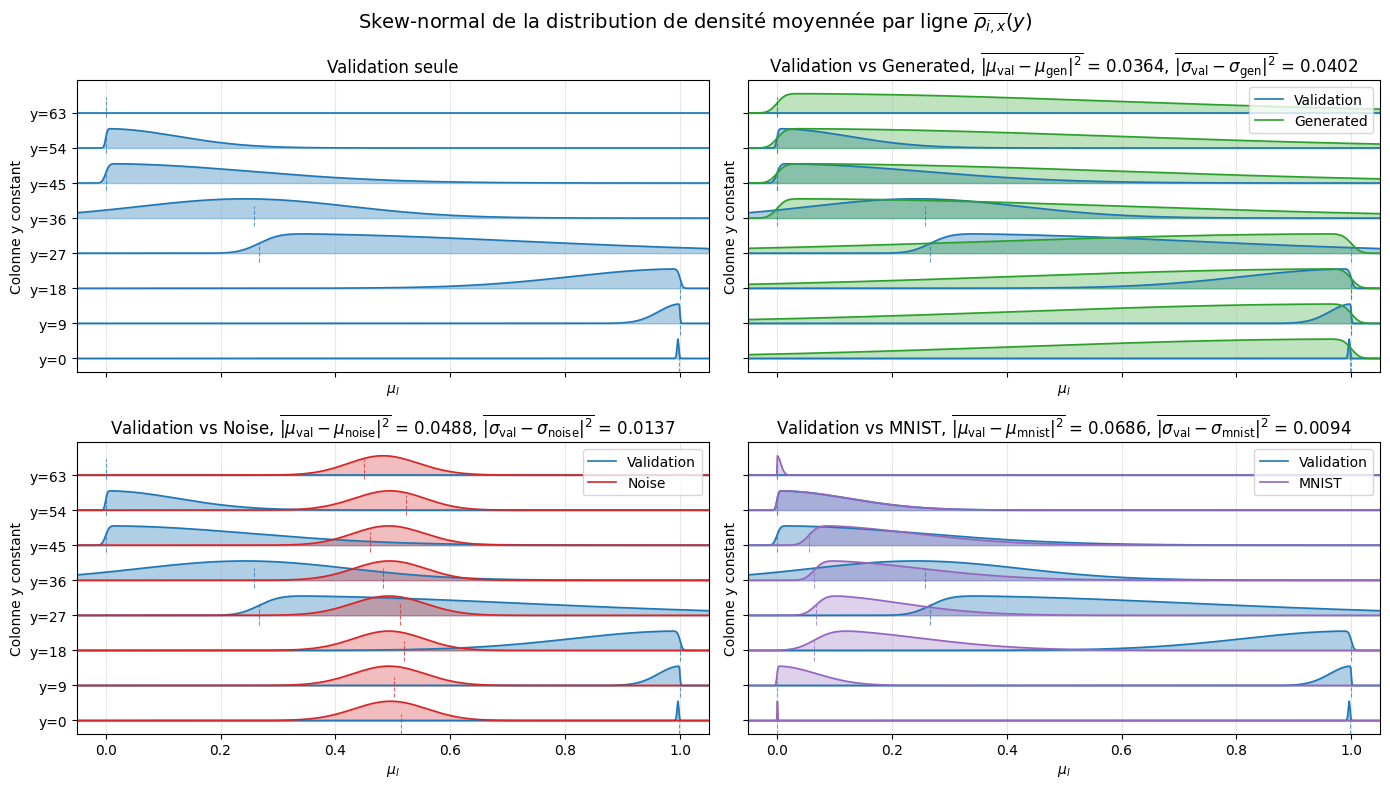

In [ ]:
title_2 = (
    "Validation vs Generated, "
    r"$\overline{|\mu_{\mathrm{val}} - \mu_{\mathrm{gen}}|^2}$"
    f" = {mu_l_dist_gen:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{gen}}|^2}$"
    f" = {sigma_l_dist_gen:.4f}"
)
title_3 = (
    "Validation vs Noise, "
    r"$\overline{|\mu_{\mathrm{val}} - \mu_{\mathrm{noise}}|^2}$"
    f" = {mu_l_dist_noise:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{noise}}|^2}$"
    f" = {sigma_l_dist_noise:.4f}"
)
title_4 = (
    "Validation vs MNIST, "
    r"$\overline{|\mu_{\mathrm{val}} - \mu_{\mathrm{mnist}}|^2}$"
    f" = {mu_l_dist_mnist:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{mnist}}|^2}$"
    f" = {sigma_l_dist_mnist:.4f}"
)

n_curves = 8
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, ax=axes[0, 0], title="Validation seule")
plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_generated, loc_l_generated, scale_l_generated, ax=axes[0, 1], title=title_2, label2="Generated", color2="tab:green")
plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_noise, loc_l_noise, scale_l_noise, ax=axes[1, 0], title=title_3, label2="Noise", color2="tab:red")
plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_mnist, loc_l_mnist, scale_l_mnist, ax=axes[1, 1], title=title_4, label2="MNIST", color2="tab:purple")

fig.suptitle(r"Skew-normal de la distribution de densité moyennée par ligne $\overline{\rho_{i,x}}(y)$", fontsize=14)
fig.tight_layout()
plt.savefig("skewnorm_joyplot.png", bbox_inches="tight")
plt.show()

### Energie spectrale des fluctuations par lignes

On applique ici la meme logique de comparaison par lignes, mais sur une representation spectrale des fluctuations. Pour un champ $\rho(t,x,y)$, on definit d'abord la fluctuation globale :
$$ \delta\rho(t,x,y) = \left|\rho(t,x,y)-\langle\rho\rangle_{t,x,y}\right|. $$

On calcule ensuite sa transformee de Fourier. Lorsque l'axe choisi est $x$, on utilise une FFT 1D :
$$ \widehat{\delta\rho}(t,k_x,y) = \mathcal{F}_x\left[\delta\rho(t,x,y)\right]. $$
Pour une transformation 2D, on utilise plutot :
$$ \widehat{\delta\rho}(t,k_x,k_y) = \mathcal{F}_{x,y}\left[\delta\rho(t,x,y)\right]. $$

L'energie spectrale est alors definie comme le module au carre :
$$ E_{\rho}(t,k_x,y) = \left|\widehat{\delta\rho}(t,k_x,y)\right|^2. $$

La fonction `line_metric` peut ensuite etre reappliquee a $E_{\rho}$ et $E_{\varrho}$ : la moyenne par ligne devient une moyenne de l'energie sur l'axe restant, et les distances comparent les profils spectraux moyens et leurs fluctuations temporelles.


In [ ]:
def transformation_Fluctuation_Eenergy_Spectrum(data, ax):
    """Calcule le spectre d'energie des fluctuations d'un champ.

    Args:
        data (torch.Tensor | np.ndarray): Champ de forme ``(t, x, y)`` ou
            ``(t, 1, x, y)``.
        ax (int): Axe de Fourier. ``-1`` applique une FFT 2D sur ``(x, y)`` ;
            toute autre valeur applique une FFT 1D sur cet axe.

    Returns:
        np.ndarray: Spectre d'energie ``|FFT(delta rho)|^2`` de forme compatible
            avec l'entree convertie en ``(t, x, y)``.
    """
    data = as_txy_numpy(data)
    fluctuation_val = np.abs(data - data.mean())

    if ax == -1:
        fluctuation_spectrum_val = np.fft.fftshift(np.fft.fft2(fluctuation_val, axes=(-2, -1)), axes=(-2, -1))
    else:
        fluctuation_spectrum_val = np.fft.fftshift(
            np.fft.fft(fluctuation_val, axis=ax),
            axes=ax,
        )

    energy_spectrum_val = np.abs(fluctuation_spectrum_val) ** 2
    return energy_spectrum_val


In [ ]:
Smu_l_dist_gen, Smu_l_gen, Smu_l_val = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1), 
                                                   transformation_Fluctuation_Eenergy_Spectrum(generated_stats, 1), 
                                                   metric_name="mu")
Smu_l_dist_noise, Smu_l_noise, _ = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1),
                                                transformation_Fluctuation_Eenergy_Spectrum(noise_stats, 1),
                                                metric_name="mu")
Smu_l_dist_mnist, Smu_l_mnist, _ = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1),
                                                transformation_Fluctuation_Eenergy_Spectrum(mnist_stats, 1),
                                                metric_name="mu")

Ssigma_l_dist_gen, Ssigma_l_gen, Ssigma_l_val = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1),
                                                    transformation_Fluctuation_Eenergy_Spectrum(generated_stats, 1),
                                                    metric_name="sigma")
Ssigma_l_dist_noise, Ssigma_l_noise, _ = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1), 
                                                     transformation_Fluctuation_Eenergy_Spectrum(noise_stats, 1), 
                                                     metric_name="sigma")
Ssigma_l_dist_mnist, Ssigma_l_mnist, _ = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1), 
                                                     transformation_Fluctuation_Eenergy_Spectrum(mnist_stats, 1), 
                                                     metric_name="sigma")

Salpha_l_val, Sloc_l_val, Sscale_l_val = get_alpha(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1))
Salpha_l_generated, Sloc_l_generated, Sscale_l_generated = get_alpha(transformation_Fluctuation_Eenergy_Spectrum(generated_stats, 1))
Salpha_l_mnist, Sloc_l_mnist, Sscale_l_mnist = get_alpha(transformation_Fluctuation_Eenergy_Spectrum(mnist_stats, 1))
Salpha_l_noise, Sloc_l_noise, Sscale_l_noise = get_alpha(transformation_Fluctuation_Eenergy_Spectrum(noise_stats, 1))

KeyboardInterrupt: 

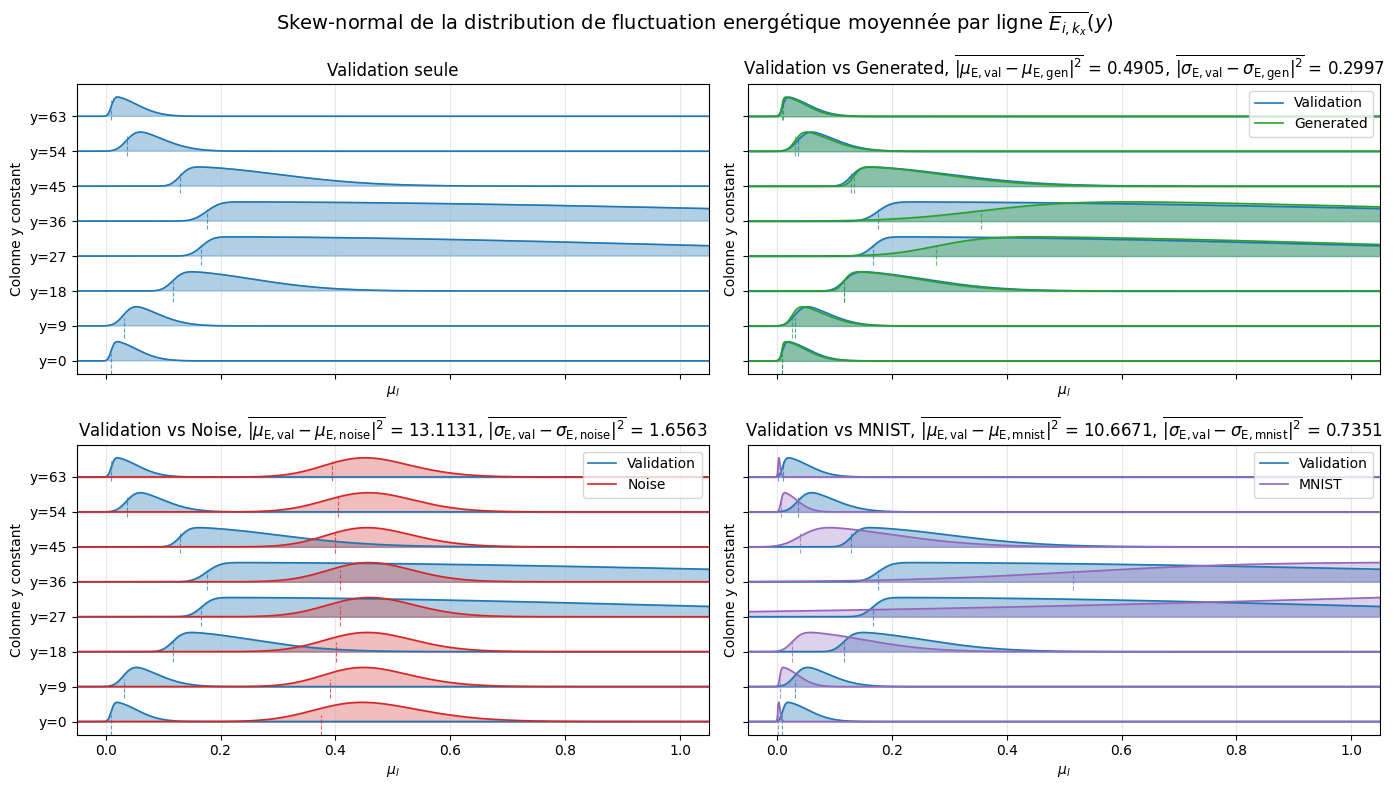

In [ ]:
title_2 = (
    "Validation vs Generated, "
    r"$\overline{|\mu_{\mathrm{E,val}} - \mu_{\mathrm{E,gen}}|^2}$"
    f" = {Smu_l_dist_gen:.4f}, "
    r"$\overline{|\sigma_{\mathrm{E,val}} - \sigma_{\mathrm{E,gen}}|^2}$"
    f" = {Ssigma_l_dist_gen:.4f}"
)
title_3 = (
    "Validation vs Noise, "
    r"$\overline{|\mu_{\mathrm{E,val}} - \mu_{\mathrm{E,noise}}|^2}$"
    f" = {Smu_l_dist_noise:.4f}, "
    r"$\overline{|\sigma_{\mathrm{E,val}} - \sigma_{\mathrm{E,noise}}|^2}$"
    f" = {Ssigma_l_dist_noise:.4f}"
)
title_4 = (
    "Validation vs MNIST, "
    r"$\overline{|\mu_{\mathrm{E,val}} - \mu_{\mathrm{E,mnist}}|^2}$"
    f" = {Smu_l_dist_mnist:.4f}, "
    r"$\overline{|\sigma_{\mathrm{E,val}} - \sigma_{\mathrm{E,mnist}}|^2}$"
    f" = {Ssigma_l_dist_mnist:.4f}"
)

n_curves = 8
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

plot_skewnorm_joyplot(n_curves, Salpha_l_val, Sloc_l_val, Sscale_l_val, ax=axes[0, 0], title="Validation seule", x_max=3)
plot_skewnorm_joyplot(n_curves, Salpha_l_val, Sloc_l_val, Sscale_l_val, Salpha_l_generated, Sloc_l_generated, Sscale_l_generated, ax=axes[0, 1], title=title_2, label2="Generated", color2="tab:green")
plot_skewnorm_joyplot(n_curves, Salpha_l_val, Sloc_l_val, Sscale_l_val, Salpha_l_noise, Sloc_l_noise, Sscale_l_noise, ax=axes[1, 0], title=title_3, label2="Noise", color2="tab:red")
plot_skewnorm_joyplot(n_curves, Salpha_l_val, Sloc_l_val, Sscale_l_val, Salpha_l_mnist, Sloc_l_mnist, Sscale_l_mnist, ax=axes[1, 1], title=title_4, label2="MNIST", color2="tab:purple")

fig.suptitle(r"Skew-normal de la distribution de fluctuation energétique moyennée par ligne $\overline{E_{i,k_x}}(y)$", fontsize=14)
fig.tight_layout()
fig.savefig("skewnorm_joyplot_energy_spectrum.png", bbox_inches="tight")
plt.show()

---
Annexe et Visualisation supplémentaires.

/tmp/ipykernel_30318/2974853453.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  fluctuation_val = np.abs(val_stats - val_stats.mean())


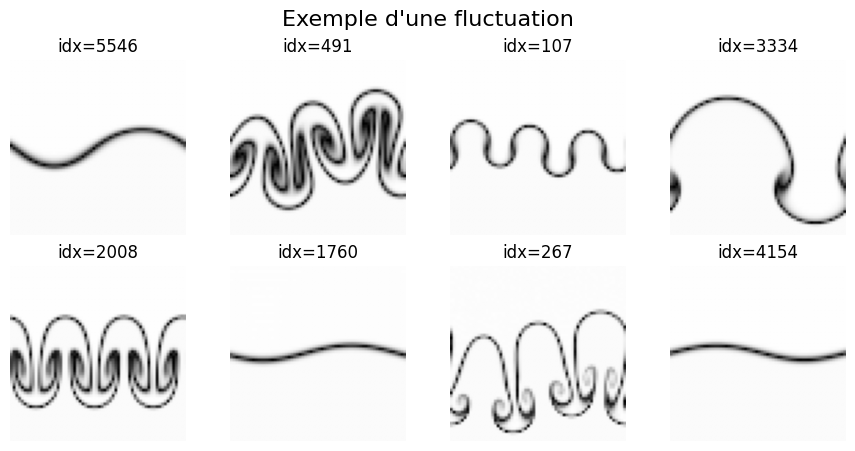

In [ ]:
fluctuation_val = np.abs(val_stats - val_stats.mean())
show_grid(fluctuation_val, n=8, cols=4, save=False, save_path="fluctuation.png", title="Exemple d'une fluctuation", colorbar=False)


/tmp/ipykernel_30318/2325679466.py:6: RuntimeWarning: divide by zero encountered in log
  show_grid(abs(np.log(fluctuation_spectrum_val)), n=8, cols=4, save=False, save_path="fluctuation_spectrum.png", title="Log du Spectre de la fluctuation", colorbar=False)


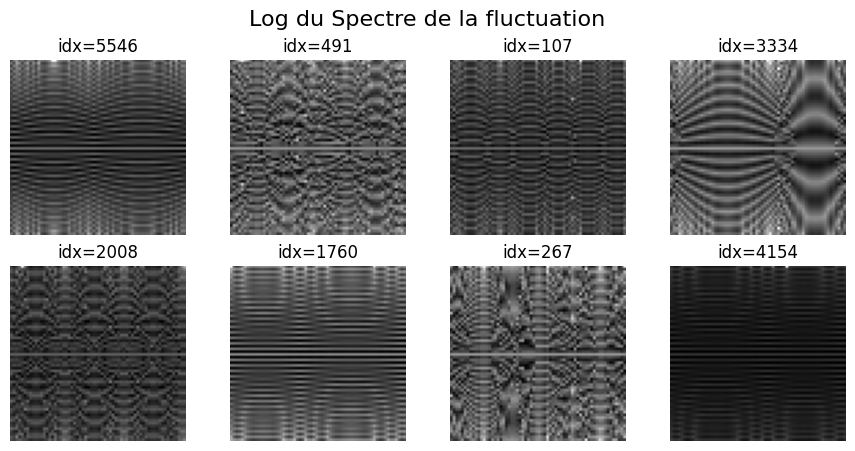

In [ ]:
# fluctuation_spectrum_val = np.fft.fftshift(np.fft.fft2(fluctuation_val, axes=(-2, -1)), axes=(-2, -1))
fluctuation_spectrum_val = np.fft.fftshift(
    np.fft.fft(fluctuation_val, axis=1),
    axes=1
)
show_grid(abs(np.log(fluctuation_spectrum_val)), n=8, cols=4, save=False, save_path="fluctuation_spectrum.png", title="Log du Spectre de la fluctuation", colorbar=False)

/tmp/ipykernel_30318/3316815640.py:2: RuntimeWarning: divide by zero encountered in log
  show_grid(np.log(energy_spectrum_val), n=8, cols=4, save=False, save_path="energy_spectrum.png", title="Log du Spectre d'énergie de la fluctuation", colorbar=False)


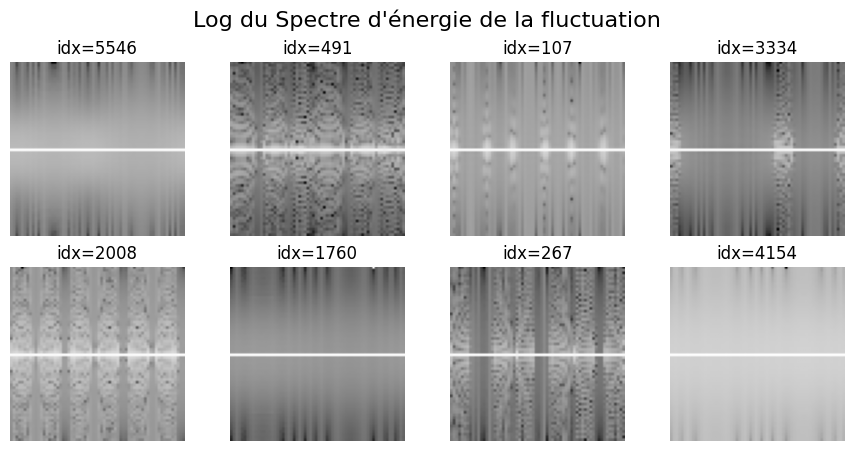

In [ ]:
energy_spectrum_val = np.abs(fluctuation_spectrum_val) ** 2
show_grid(np.log(energy_spectrum_val), n=8, cols=4, save=False, save_path="energy_spectrum.png", title="Log du Spectre d'énergie de la fluctuation", colorbar=False)